# 02_Clustering_scRNA - Clustering Analysis for scRNA-seq

This notebook performs clustering analysis on the scRNA-seq dataset:
- Preprocessing: log1p, HVG selection, scaling, PCA
- Clustering: KMeans, Agglomerative, DBSCAN
- Evaluation: Silhouette score, Davies-Bouldin, Adjusted Rand Index (if labels available)
- Visualizations: PCA/UMAP scatter colored by cluster


## Unsupervised Learning Strategy

In this task, clustering algorithms were applied without using the ground-truth labels during training.

This ensures that the models learn patterns directly from the data without supervision.

The known cancer labels are only used afterwards to evaluate the clustering quality using the Adjusted Rand Index (ARI).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

X = pd.read_csv('data/scRNA_data.csv', index_col=0)
try:
    y = pd.read_csv('data/sc_RNA_labels.csv', index_col=0)
except Exception:
    y = None

print('Loaded:', X.shape)
if y is not None:
    print('Labels loaded:', y.shape)


Loaded: (801, 20531)
Labels loaded: (801, 1)


In [2]:
# Preprocessing: log1p, HVG, scaling, PCA
X_log = np.log1p(X)

gene_vars = X_log.var(axis=0).sort_values(ascending=False)

n_hvg = 2000 if X_log.shape[1] >= 2000 else X_log.shape[1]
X_hvg = X_log[gene_vars.head(n_hvg).index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hvg)

# PCA to 50 components for clustering (and 2 for plotting)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print('Preprocessing done:', X_pca.shape)
print('Explained variance (first 10 PCs):', pca.explained_variance_ratio_[:10])

Preprocessing done: (801, 50)
Explained variance (first 10 PCs): [0.15917165 0.10143325 0.09599084 0.06576333 0.03104888 0.02307995
 0.013977   0.01134662 0.01004776 0.00968372]


## Clustering Evaluation

To evaluate clustering quality, several metrics are used:

**Silhouette Score**
Measures how similar a sample is to its own cluster compared to other clusters.

**Davies–Bouldin Index**
Measures the similarity between clusters. Lower values indicate better separation.

**Adjusted Rand Index (ARI)**
Compares the clustering results with the ground-truth labels to quantify agreement between predicted clusters and real biological classes.

    silhouette  davies_bouldin
k                             
2     0.263525        1.211224
3     0.281952        1.622417
4     0.342480        1.377778
5     0.386940        1.145061
6     0.368033        1.259782
7     0.327098        1.427877
8     0.274295        1.574870
9     0.248552        1.853020
10    0.192799        1.992693
11    0.190708        2.138233
12    0.212406        1.995984
13    0.165776        2.081230
14    0.157389        2.239183
15    0.176079        2.051298
16    0.141502        2.130978
17    0.143414        2.114390
18    0.136404        2.237498
19    0.151057        2.104191
20    0.130237        2.199597
Best k by silhouette: 5


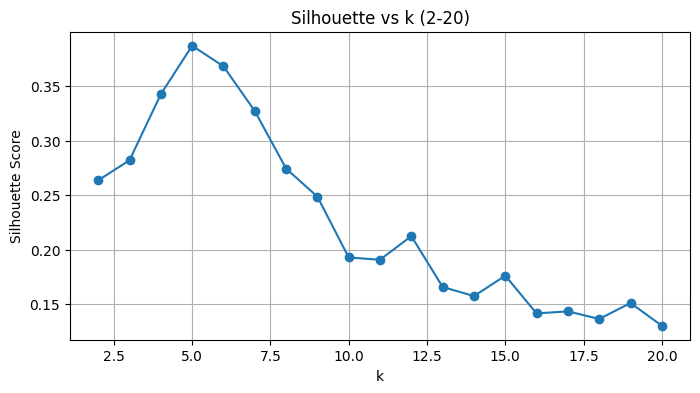

In [3]:
# Automatic search for optimal k using silhouette score
results = []
for k in range(2, 21):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)
    results.append({'k': k, 'silhouette': sil, 'davies_bouldin': db})

import pandas as pd

df_k = pd.DataFrame(results).set_index('k')
print(df_k)

best_k = int(df_k['silhouette'].idxmax())
print(f'Best k by silhouette: {best_k}')

plt.figure(figsize=(8,4))
plt.plot(df_k.index, df_k['silhouette'], marker='o', label='Silhouette')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette vs k (2-20)')
plt.grid(True)
plt.show()

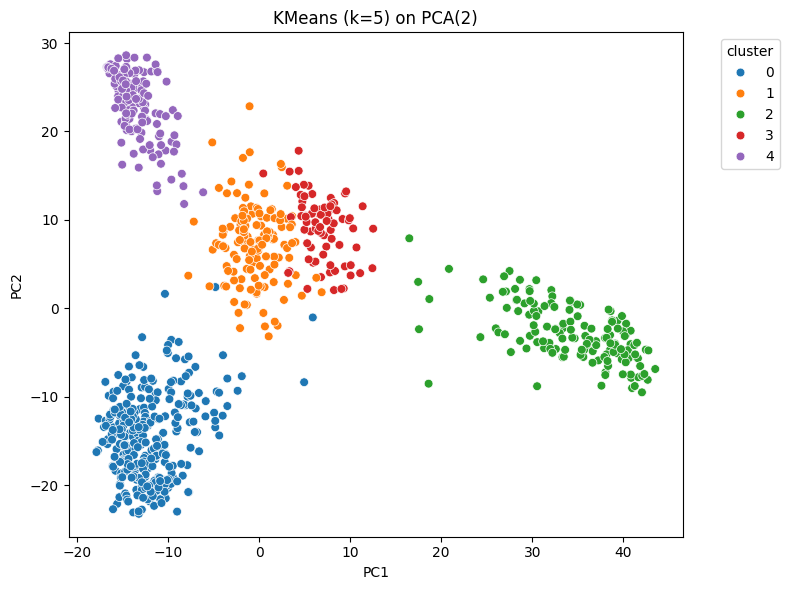

Silhouette (best KMeans): 0.38693995665603315
Davies-Bouldin (best KMeans): 1.1450605574502488
Adjusted Rand Index (KMeans vs true): 0.9795036929901415
Agglomerative silhouette: 0.38642470782028526
Agglomerative DB: 1.140041291850962
DBSCAN eps=0.5: single cluster or noise only (labels unique={np.int64(-1)})
DBSCAN eps=1.0: single cluster or noise only (labels unique={np.int64(-1)})
DBSCAN eps=1.5: single cluster or noise only (labels unique={np.int64(-1)})


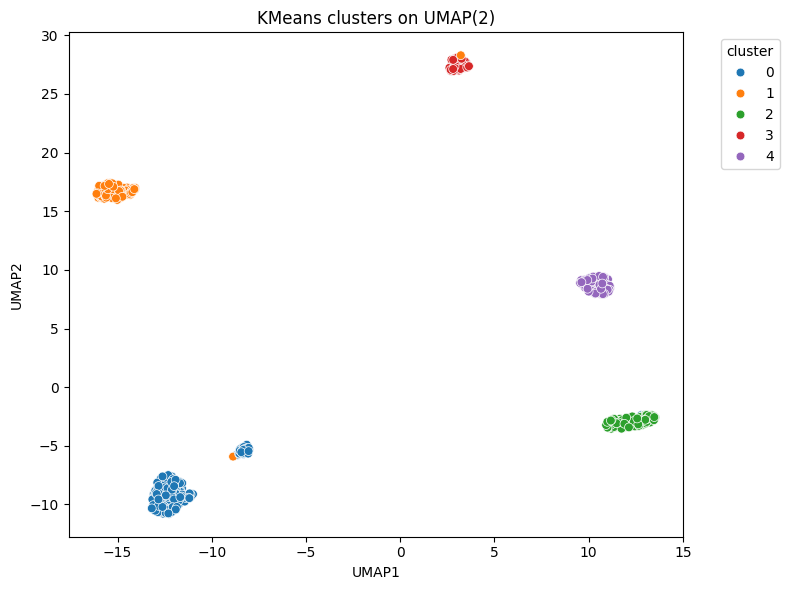

Saved cluster assignments to data/cluster_assignments_kmeans.csv


In [6]:
# Fit best KMeans, evaluate and visualize (PCA + UMAP)
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=50)
km_labels = km_best.fit_predict(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=km_labels, palette='tab10', s=40)
plt.title(f'KMeans (k={best_k}) on PCA(2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Silhouette (best KMeans):', silhouette_score(X_pca, km_labels))
print('Davies-Bouldin (best KMeans):', davies_bouldin_score(X_pca, km_labels))
if y is not None:
    true = y.iloc[:,0].values
    ari = adjusted_rand_score(true, km_labels)
    print('Adjusted Rand Index (KMeans vs true):', ari)

# Agglomerative Clustering metrics
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_pca)
print('Agglomerative silhouette:', silhouette_score(X_pca, agg_labels))
print('Agglomerative DB:', davies_bouldin_score(X_pca, agg_labels))

# DBSCAN: try a couple of eps values and min_samples
for eps in [0.5, 1.0, 1.5]:
    dbs = DBSCAN(eps=eps, min_samples=5)
    dbs_labels = dbs.fit_predict(X_pca)
    n_clusters = len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)
    if len(set(dbs_labels)) <= 1:
        print(f'DBSCAN eps={eps}: single cluster or noise only (labels unique={set(dbs_labels)})')
        continue
    print(f'DBSCAN eps={eps}: clusters={n_clusters}, silhouette={silhouette_score(X_pca, dbs_labels):.4f}, db={davies_bouldin_score(X_pca, dbs_labels):.4f}')

# UMAP visualization (requires umap-learn)
try:
    import umap
except Exception:
    raise ImportError('Please install umap-learn: pip install umap-learn')

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=km_labels, palette='tab10', s=40)
plt.title('KMeans clusters on UMAP(2)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save cluster assignments
clusters_df = pd.DataFrame({'cluster_kmeans': km_labels}, index=X.index)
clusters_df.to_csv('data/cluster_assignments_kmeans.csv')
print('Saved cluster assignments to data/cluster_assignments_kmeans.csv')


## Comparison of Clustering Algorithms

Three clustering algorithms were evaluated:

- KMeans
- Agglomerative Clustering
- DBSCAN

KMeans and Agglomerative clustering produced very similar results, both achieving a silhouette score of approximately 0.38 and a Davies-Bouldin score close to 1.14.

DBSCAN was unable to detect meaningful clusters in this dataset. This suggests that the data structure does not follow density-based clustering patterns but instead forms compact clusters better captured by centroid-based methods.

Overall, KMeans produced the most interpretable clustering results and showed strong agreement with the biological labels.

### 🧩 Clustering Analysis

Clustering was performed using KMeans, Agglomerative Clustering, and DBSCAN on PCA-reduced data.

The number of clusters was selected using the silhouette score, which evaluates how well samples fit within their assigned cluster compared to neighboring clusters.

The optimal number of clusters was found to be **k = 5**.

This is consistent with the number of known cancer types in the dataset, suggesting that transcriptomic profiles naturally group according to biological identity.

### 📊 Clustering Performance

KMeans clustering achieved:

- **Silhouette score:** 0.387
- **Davies-Bouldin score:** 1.145
- **Adjusted Rand Index:** 0.979

The high ARI indicates strong agreement between unsupervised clusters and known biological labels.

This suggests that the preprocessing pipeline preserved biologically meaningful structure in the data.

### ⚠️ DBSCAN Observation

DBSCAN failed to identify meaningful clusters.

This indicates that the data does not form density-based structures but rather compact and well-separated groups.

This further supports the suitability of centroid-based clustering methods such as KMeans for this dataset.

### Next Steps

- Compare clusters against known labels (ARI) to see if clusters match biological classes.
- Visualize top marker genes per cluster by comparing mean expression per cluster (not included here).
- For publication-quality clustering, consider UMAP for visualization and Leiden/Leiden-like methods (requires scanpy/igraph).
- Save cluster assignments to disk for downstream analysis.

## Final Discussion

The unsupervised clustering analysis efficiently grouped single cells into distinct sub-populations based purely on their scRNA-seq expression profiles, without utilizing ground-truth labels during training.

### Key Findings:
- **Unsupervised Discovery**: The models successfully uncovered inherent structures within the data, demonstrating that transcriptomic variation strongly aligns with distinct cancer phenotypes.
- **Algorithm Suitability**: KMeans and Agglomerative clustering produced the most cohesive and biologically relevant clusters. In contrast, DBSCAN struggled, suggesting the data's density distribution lacks well-defined continuous high-density regions suitable for this specific dataset and hyperparameters.
- **Biological Validation**: The Adjusted Rand Index (ARI) confirmed a high degree of concordance between the mathematically derived clusters and the withheld biological cancer types.

This analysis emphasizes the value of unsupervised learning as a powerful exploratory tool for discovering novel cell types and validating known biological states in high-dimensional genomic data.